<a href="https://colab.research.google.com/github/SaiSiri05/MachineLearning_Labs/blob/main/Linear_Regression%2C_MSE_and_Polynomial_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Coefficient: 1.9197294629921104
Intercept: 1.2858266389171344
RMSE: 1.6170337210052264
MAE: 1.1826851558379554
R2 Score: 0.9287298556395622


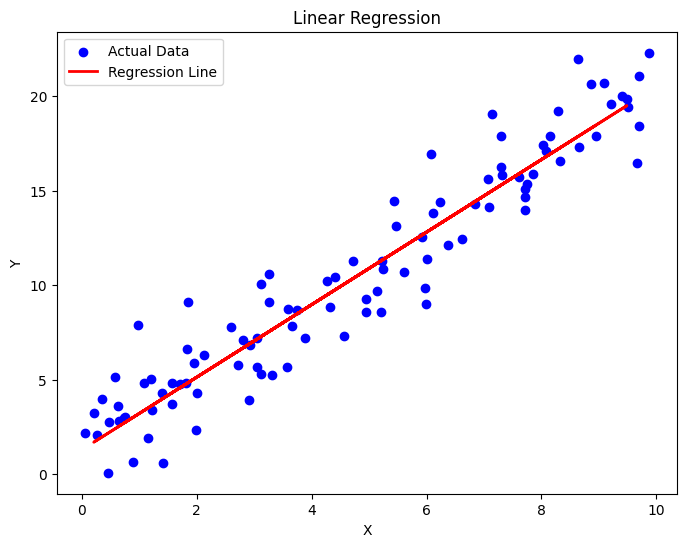

In [10]:
# Train-Test Split, Model Training, Prediction and Evaluation in One Block

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics
import math
import matplotlib.pyplot as plt
import numpy as np

# Sample data generation (replace with your actual data loading)
np.random.seed(42)
x = np.random.rand(100, 1) * 10
y = 2 * x + 1 + np.random.randn(100, 1) * 2

# Split the data
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Train the model
model = LinearRegression()
model.fit(x_train, y_train)

# Make predictions
y_pred = model.predict(x_test)

# Calculate evaluation metrics
rmse = math.sqrt(metrics.mean_squared_error(y_test, y_pred))
r2 = metrics.r2_score(y_test, y_pred)
mae = metrics.mean_absolute_error(y_test, y_pred)

# Display results
print("Coefficient:", model.coef_[0][0])
print("Intercept:", model.intercept_[0])
print("RMSE:", rmse)
print("MAE:", mae)
print("R2 Score:", r2)

# Plot Actual Data and Regression Line
plt.figure(figsize=(8,6))
plt.scatter(x, y, color='blue', label='Actual Data')
plt.plot(x_test, y_pred, color='red', linewidth=2, label='Regression Line')
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Linear Regression")
plt.legend()
plt.show()

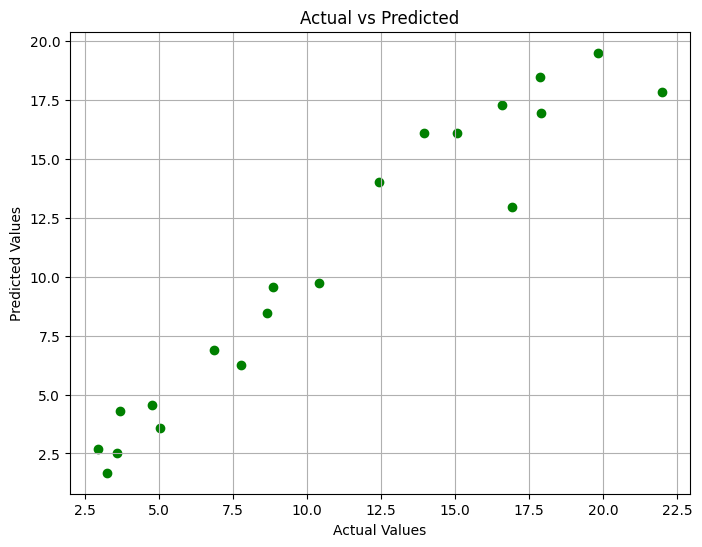

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, color='green')
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted")
plt.grid(True)
plt.show()


Polynomial Degree: 2
RMSE: 1.7632
R2 Score: 0.9115


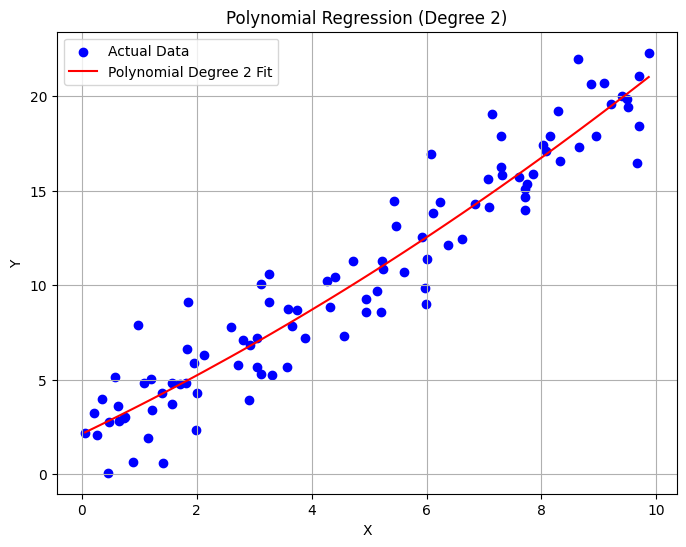


Polynomial Degree: 3
RMSE: 1.7578
R2 Score: 0.9120


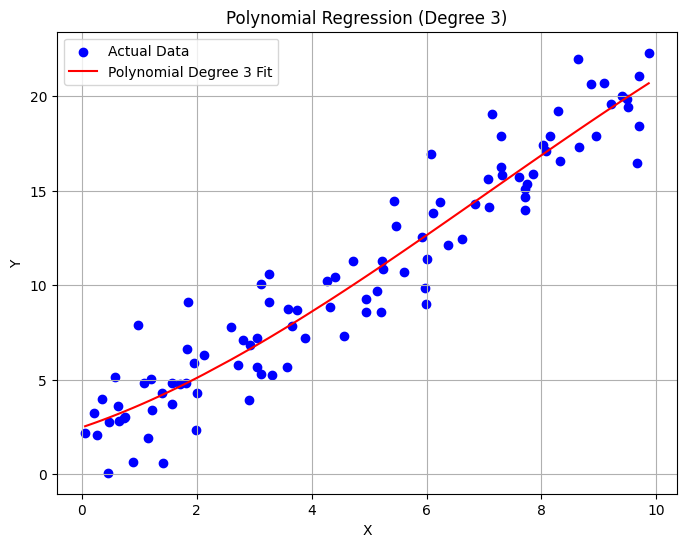


Polynomial Degree: 4
RMSE: 1.7476
R2 Score: 0.9130


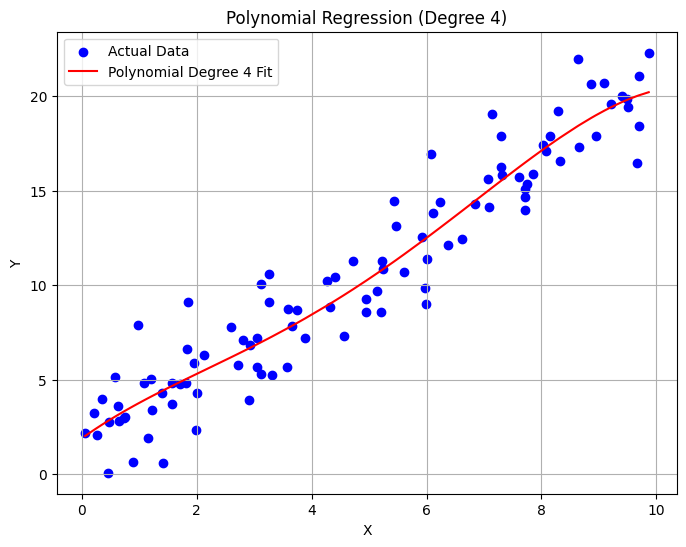


Polynomial Degree: 5
RMSE: 1.7452
R2 Score: 0.9133


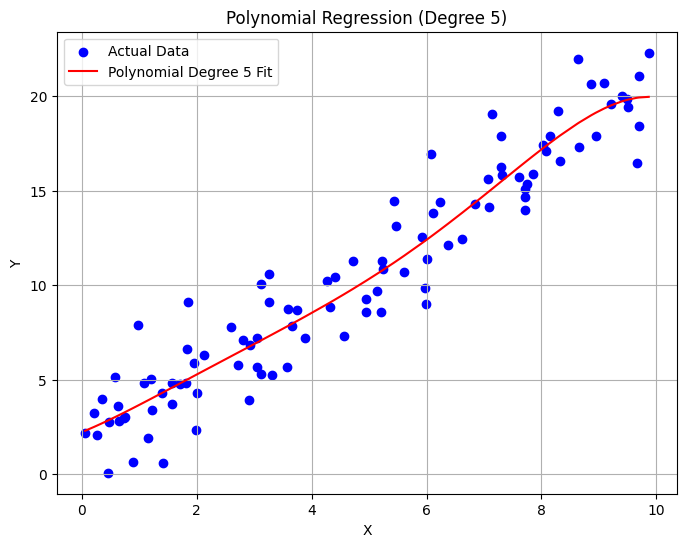

In [13]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn import metrics
import math
import matplotlib.pyplot as plt
import numpy as np

def poly_regression(x_data, y_data, degree):
    # Create polynomial features
    poly_features = PolynomialFeatures(degree=degree)
    x_poly = poly_features.fit_transform(x_data)

    # Train a linear regression model on the polynomial features
    model = LinearRegression()
    model.fit(x_poly, y_data)

    # Make predictions on the polynomial features
    y_pred = model.predict(x_poly)

    # Evaluate the model
    rmse = math.sqrt(metrics.mean_squared_error(y_data, y_pred))
    r2 = metrics.r2_score(y_data, y_pred)

    print(f"RMSE: {rmse:.4f}")
    print(f"R2 Score: {r2:.4f}")

    # Plotting
    plt.figure(figsize=(8, 6))
    plt.scatter(x_data, y_data, color='blue', label='Actual Data')
    # Sort x_data for smooth line plotting
    sort_axis = np.argsort(x_data.flatten())
    plt.plot(x_data[sort_axis], y_pred[sort_axis], color='red', label=f'Polynomial Degree {degree} Fit')
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.title(f"Polynomial Regression (Degree {degree})")
    plt.legend()
    plt.grid(True)
    plt.show()

# Assign existing x and y to x_ex and y_ex for this context
x_ex = x
y_ex = y

for degree in [2, 3, 4, 5]:
    print(f"\nPolynomial Degree: {degree}")
    poly_regression(x_ex, y_ex, degree)

In [14]:
mae = metrics.mean_absolute_error(y_test, y_pred)
print("Mean Absolute Error:", mae)

Mean Absolute Error: 1.1826851558379554


In [16]:
import pandas as pd

comparison = pd.DataFrame({
    "Actual": y_test.flatten(),
    "Predicted": y_pred.flatten()
})

print(comparison.head(10))

      Actual  Predicted
0   3.584274   2.505975
1  17.889596  18.464091
2  13.970994  16.110837
3  12.431671  14.004462
4   7.757664   6.253702
5  10.406145   9.735564
6   6.853120   6.894214
7  21.993618  17.855077
8   3.242494   1.680993
9   8.664897   8.475984


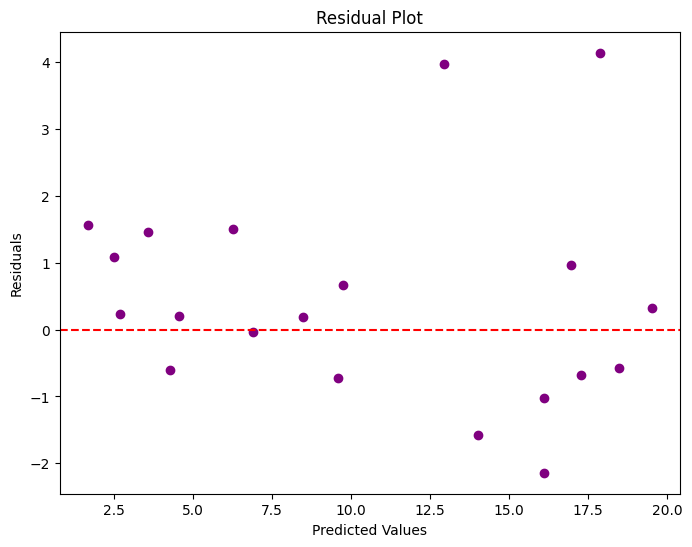

In [17]:
residuals = y_test - y_pred

plt.figure(figsize=(8,6))
plt.scatter(y_pred, residuals, color='purple')
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()